In [ ]:
!pip install snorkel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
!pip install transformers datasets torch scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.1 MB/s eta 0:00:00


In [ ]:
import re
import pandas as pd
import spacy
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset
from snorkel.labeling.model import LabelModel
from sklearn.model_selection import train_test_split


In [ ]:
ABSTAIN = -1
POSITIVE = 1
NEGATIVE = 0

In [ ]:
df = pd.read_csv("/content/snorkel_weakly_labeled (1).csv")
df = df.dropna(subset=["text"])  # Remove missing values


In [ ]:
df["snorkel_label"] = df["snorkel_label"].astype(int)


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["snorkel_label"], test_size=0.2, random_state=42
)

In [ ]:
train_data = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
test_data = Dataset.from_dict({"text": test_texts.tolist(), "label": test_labels.tolist()})

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
from transformers import AutoConfig


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=2)


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.classifier.weight.data.normal_(mean=0.0, std=config.initializer_range)
model.classifier.bias.data.zero_()


tensor([0., 0.])

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)


In [ ]:
train_data = train_data.map(tokenize_function, batched=True)
test_data = test_data.map(tokenize_function, batched=True)


Map:   0%|          | 0/3535 [00:00<?, ? examples/s]

Map:   0%|          | 0/884 [00:00<?, ? examples/s]

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [ ]:
gradient_accumulation_steps=4,


In [ ]:
training_args = TrainingArguments(
    report_to="none",
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    fp16=True,  # Enable Mixed Precision
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=data_collator,
)


In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,0.202900,0.201093
2,0.108900,0.244959
3,0.032700,0.235796


TrainOutput(global_step=333, training_loss=0.13278230912871547, metrics={'train_runtime': 150.9178, 'train_samples_per_second': 70.27, 'train_steps_per_second': 2.206, 'total_flos': 1404816762746880.0, 'train_loss': 0.13278230912871547, 'epoch': 3.0})

In [ ]:
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

Evaluation Results: {'eval_loss': 0.235795795917511, 'eval_runtime': 4.0833, 'eval_samples_per_second': 216.489, 'eval_steps_per_second': 6.857, 'epoch': 3.0}


In [ ]:
y_pred = trainer.predict(test_data)
pred_labels = y_pred.predictions.argmax(axis=1)

In [ ]:
accuracy = accuracy_score(test_labels, pred_labels)
print("Accuracy:", accuracy)


Accuracy: 0.9321266968325792


In [ ]:
print("Classification Report:")
print(classification_report(test_labels, pred_labels))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       465
           1       0.91      0.95      0.93       419

    accuracy                           0.93       884
   macro avg       0.93      0.93      0.93       884
weighted avg       0.93      0.93      0.93       884



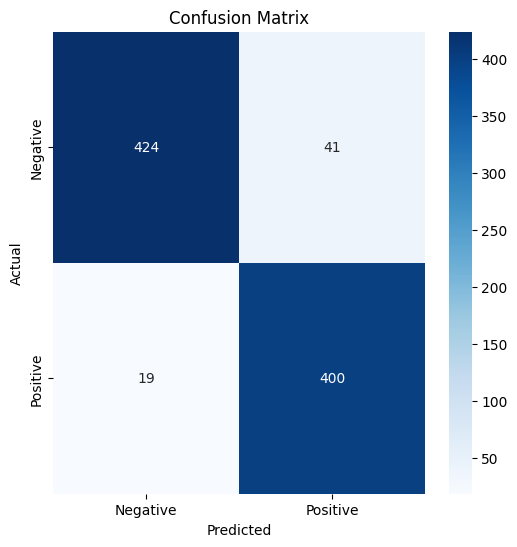

In [ ]:
conf_matrix = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

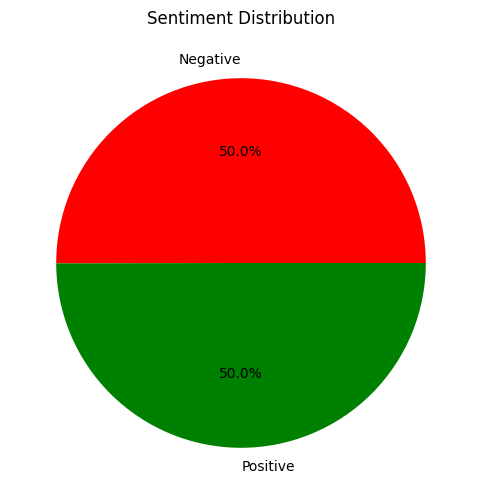

In [ ]:
plt.figure(figsize=(6,6))
labels = ["Negative", "Positive"]
plt.pie(df["snorkel_label"].value_counts(), labels=labels, autopct='%1.1f%%', colors=["red", "green"])
plt.title("Sentiment Distribution")
plt.show()

<ipython-input-28-f3e8b2427cd8>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["snorkel_label"], palette=["red", "green"])


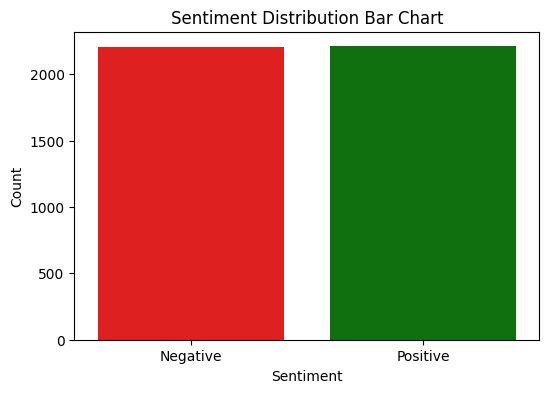

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["snorkel_label"], palette=["red", "green"])
plt.xticks(ticks=[0,1], labels=["Negative", "Positive"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution Bar Chart")
plt.show()


In [ ]:
print("✅ Sentiment Model Training and Evaluation Complete!")


✅ Sentiment Model Training and Evaluation Complete!


In [ ]:
print(classification_report(test_labels, pred_labels))


              precision    recall  f1-score   support

           0       0.96      0.91      0.93       465
           1       0.91      0.95      0.93       419

    accuracy                           0.93       884
   macro avg       0.93      0.93      0.93       884
weighted avg       0.93      0.93      0.93       884



In [ ]:
print(conf_matrix)


[[424  41]
 [ 19 400]]
